<a href="https://colab.research.google.com/github/asegura4488/FisicaA/blob/main/Semana15/Pendulo_Integradores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

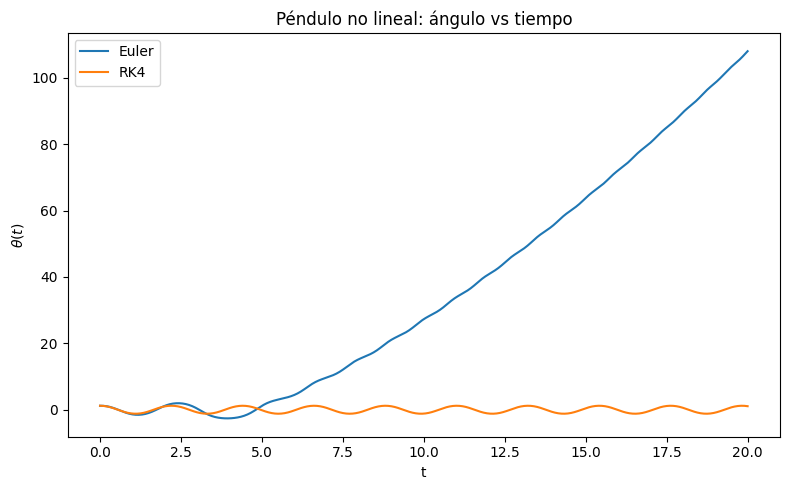

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

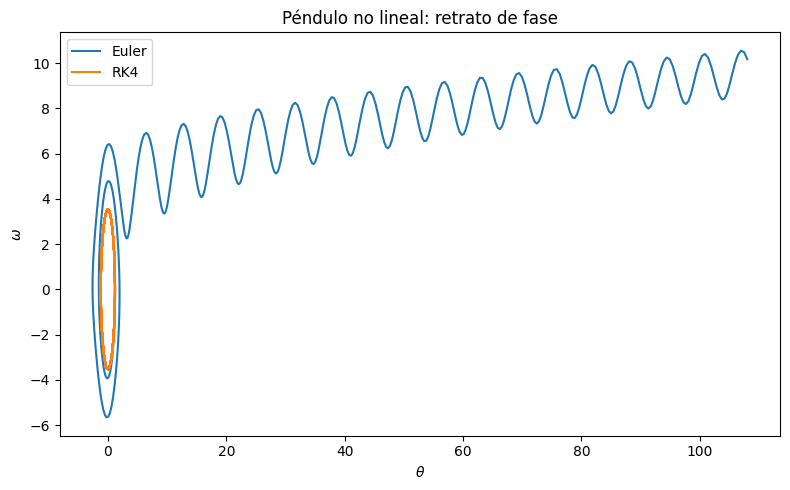

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

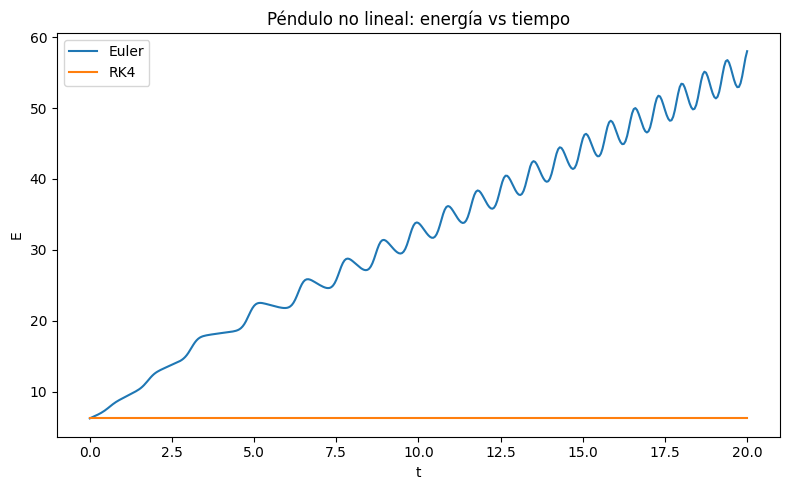

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

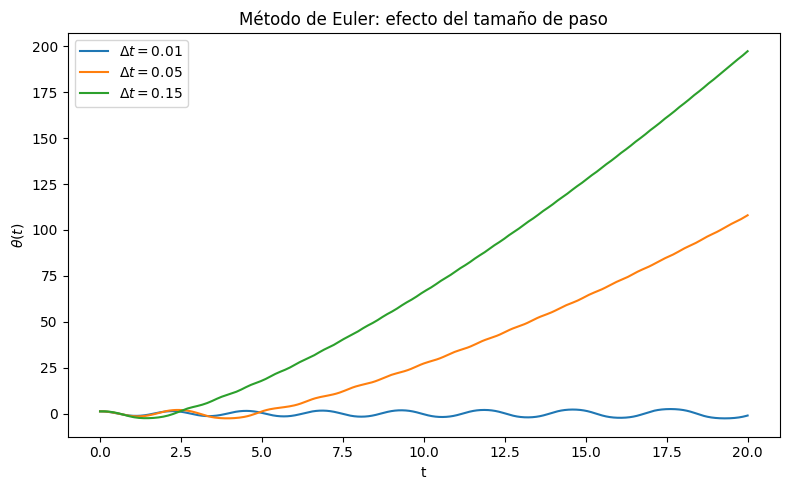

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PENDULO NO LINEAL: EULER VS RK4
Condicion inicial: theta0 = 1.2, omega0 = 0.0
Paso principal dt = 0.05
Tiempo total = 20.0

Energia inicial:
Euler: 6.25527043
RK4:   6.25527043

Energia final:
Euler: 58.00918111
RK4:   6.25493398

Cambio de energia:
Euler: 51.75391068
RK4:   -0.00033644


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =====================================================
# PENDULO NO LINEAL: EULER VS RK4
# =====================================================

# Parametros fisicos
g = 9.81
L = 1.0

# -----------------------------------------------------
# Sistema dinamico
# y = [theta, omega]
# -----------------------------------------------------
def f(y):
    theta, omega = y
    dtheta = omega
    domega = -(g / L) * np.sin(theta)
    return np.array([dtheta, domega])

# -----------------------------------------------------
# Energia mecanica
# E = 1/2 L^2 omega^2 + gL(1-cos(theta))
# -----------------------------------------------------
def energia(theta, omega):
    return 0.5 * (L**2) * omega**2 + g * L * (1.0 - np.cos(theta))

# -----------------------------------------------------
# Paso de Euler
# -----------------------------------------------------
def paso_euler(y, dt):
    return y + dt * f(y)

# -----------------------------------------------------
# Paso de RK4
# -----------------------------------------------------
def paso_rk4(y, dt):
    k1 = f(y)
    k2 = f(y + 0.5 * dt * k1)
    k3 = f(y + 0.5 * dt * k2)
    k4 = f(y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

# -----------------------------------------------------
# Integrador generico
# -----------------------------------------------------
def integrar(metodo, y0, dt, tmax):
    nsteps = int(tmax / dt)
    t = np.linspace(0, tmax, nsteps + 1)

    Y = np.zeros((nsteps + 1, 2))
    Y[0] = y0

    for n in range(nsteps):
        Y[n + 1] = metodo(Y[n], dt)

    theta = Y[:, 0]
    omega = Y[:, 1]
    E = energia(theta, omega)

    return t, theta, omega, E

# =====================================================
# CONDICIONES INICIALES
# =====================================================
theta0 = 1.2     # radianes
omega0 = 0.0
y0 = np.array([theta0, omega0])

dt = 0.05
tmax = 20.0

# =====================================================
# INTEGRACION PRINCIPAL
# =====================================================
t_e, theta_e, omega_e, E_e = integrar(paso_euler, y0, dt, tmax)
t_r, theta_r, omega_r, E_r = integrar(paso_rk4, y0, dt, tmax)

# =====================================================
# FIGURA 1: THETA VS TIEMPO
# =====================================================
plt.figure(figsize=(8, 5))
plt.plot(t_e, theta_e, label="Euler")
plt.plot(t_r, theta_r, label="RK4")
plt.xlabel("t")
plt.ylabel(r"$\theta(t)$")
plt.title("Péndulo no lineal: ángulo vs tiempo")
plt.legend()
plt.tight_layout()
plt.savefig("Pendulo_theta.pdf", dpi=300, bbox_inches="tight")
plt.show()

files.download("Pendulo_theta.pdf")

# =====================================================
# FIGURA 2: RETRATO DE FASE
# =====================================================
plt.figure(figsize=(8, 5))
plt.plot(theta_e, omega_e, label="Euler")
plt.plot(theta_r, omega_r, label="RK4")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\omega$")
plt.title("Péndulo no lineal: retrato de fase")
plt.legend()
plt.tight_layout()
plt.savefig("Pendulo_fase.pdf", dpi=300, bbox_inches="tight")
plt.show()

files.download("Pendulo_fase.pdf")

# =====================================================
# FIGURA 3: ENERGIA VS TIEMPO
# =====================================================
plt.figure(figsize=(8, 5))
plt.plot(t_e, E_e, label="Euler")
plt.plot(t_r, E_r, label="RK4")
plt.xlabel("t")
plt.ylabel("E")
plt.title("Péndulo no lineal: energía vs tiempo")
plt.legend()
plt.tight_layout()
plt.savefig("Pendulo_energia.pdf", dpi=300, bbox_inches="tight")
plt.show()

files.download("Pendulo_energia.pdf")

# =====================================================
# FIGURA 4: EFECTO DEL PASO TEMPORAL EN EULER
# =====================================================
dt_values = [0.01, 0.05, 0.15]

plt.figure(figsize=(8, 5))

for dt_test in dt_values:
    t_tmp, theta_tmp, omega_tmp, E_tmp = integrar(paso_euler, y0, dt_test, tmax)
    plt.plot(t_tmp, theta_tmp, label=fr"$\Delta t={dt_test}$")

plt.xlabel("t")
plt.ylabel(r"$\theta(t)$")
plt.title("Método de Euler: efecto del tamaño de paso")
plt.legend()
plt.tight_layout()
plt.savefig("Pendulo_dt.pdf", dpi=300, bbox_inches="tight")
plt.show()

files.download("Pendulo_dt.pdf")

# =====================================================
# RESUMEN NUMERICO
# =====================================================
print("===================================")
print("PENDULO NO LINEAL: EULER VS RK4")
print("===================================")
print(f"Condicion inicial: theta0 = {theta0}, omega0 = {omega0}")
print(f"Paso principal dt = {dt}")
print(f"Tiempo total = {tmax}")
print("")
print("Energia inicial:")
print(f"Euler: {E_e[0]:.8f}")
print(f"RK4:   {E_r[0]:.8f}")
print("")
print("Energia final:")
print(f"Euler: {E_e[-1]:.8f}")
print(f"RK4:   {E_r[-1]:.8f}")
print("")
print("Cambio de energia:")
print(f"Euler: {E_e[-1] - E_e[0]:.8f}")
print(f"RK4:   {E_r[-1] - E_r[0]:.8f}")